# Import

In [ ]:
import os
import glob
from itertools import product
import numpy as np
import graphical_sampling as gs
import pandas as pd
from tqdm import tqdm

# NHT Variance

In [10]:
N = 100
n = 4
num_zones = 4
rng = gs.random.rng()
coords = rng.rand_coord((N, 2))
variable = np.random.rand(N) * 10
# inclusions = rng.unequal_inclusions(n, N)
inclusions = variable + np.random.rand(N)
pop = gs.Population(coords, inclusions, n=n, variable=variable)

In [9]:
# df = pd.read_csv('populations/MU284_filtered.csv')
# cs82 = df['CS82'].values.astype(float)
# rmt85 = df['RMT85'].values.astype(float)
# ss82 = df['SS82'].values.astype(float)

# N = len(df)
# n = 10
# num_zones = 4
# rng = gs.random.rng()
# coords = rng.rand_coord((N, 2))
# pop = gs.Population(
#     coords=rng.rand_coord((N, 2)),
#     inclusions=ss82,
#     variable=cs82,
#     n=4
# )

In [11]:
initial_designs = [gs.Design(pop, num_partitions=num_zones) for _ in range(100)]
criteria = gs.criteria.VarNHT()
gbfs = gs.search.GreedyBestFirstSearch(initial_designs, criteria)

In [12]:
gbfs.run(
    max_iterations=1000,
    max_open_set_size=2000,
    top_k=10,
    num_new_order_nodes=0,
    num_new_exchange_nodes=5,
    num_clusters=2,
    num_zones=1,
    num_changes=2,
    num_zone_changes=1,
    random_pull=True,
    exchange_coef=1.0,
    num_explore=5
)

TypeError: GreedyBestFirstSearch.run() got an unexpected keyword argument 'random_pull'

# Spread

## Random Population

In [13]:
N = 1000
n = 4
num_zones = 4
rng = gs.random.rng()
coords = rng.rand_coord((N, 2))
variable = np.random.rand(N) * 10
# inclusions = rng.unequal_inclusions(n, N)
inclusions = variable + np.random.rand(N)
pop = gs.Population(coords, inclusions, n=n, variable=variable)

<Axes: title={'center': 'FIP Balanced 4-Means Soft Clustering with Zones'}, xlabel='$X_1$', ylabel='$X_2$'>

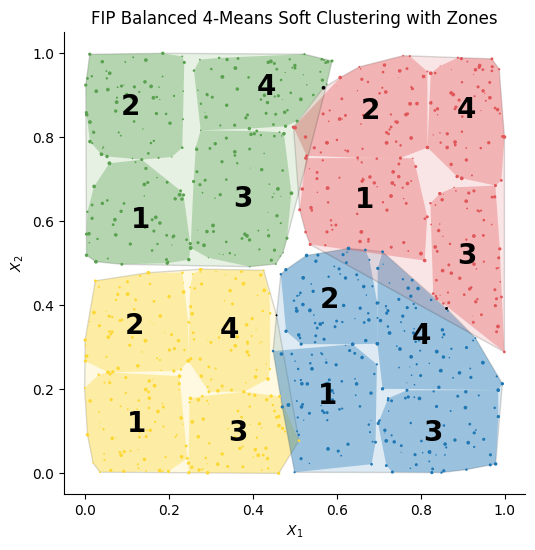

In [14]:
fbn = gs.clustering.FIPBalancedNMeans(n)
fbn.fit(pop)
fbn.fit_zones(num_zones=(2, 2), mode='sweep_xy')
fbn.plot(mode='soft')

## Paper Population

In [30]:
DATA_DIR = "/home/bardia/graphical-sampling/populations"

csv_paths = glob.glob(os.path.join(DATA_DIR, "*.csv"))

coords_dict = {}
probs_dict = {}

for fp in csv_paths:
    print(fp)
    name = os.path.splitext(os.path.basename(fp))[0]
    data = np.loadtxt(fp, delimiter=",", skiprows=1)
    print(name)
    coords = data[:, :2]
    probs  = data[:, -1]
    print(probs)
    coord_name, prob_name, *rest = name.split("_")
    coord_name = 'cluster' if coord_name == 'clust' else coord_name
    prob_name = 'equal' if prob_name == 'eq' else 'unequal'

    coords_dict[coord_name] = coords
    probs_dict[coord_name] = probs_dict.get(coord_name, {})
    probs_dict[coord_name][prob_name] = probs

print(coords_dict.keys())

/home/bardia/graphical-sampling/populations/clust_N256.csv
clust_N256
[1.44975932 3.69619438 2.71515499 0.3508746  2.16964091 0.58508894
 4.37824091 1.94377974 2.45995565 1.45695619 1.20826057 2.35603233
 0.27986793 3.33869897 2.27530452 3.64835615 2.36320503 0.72799338
 1.75247041 2.59711374 2.92198255 1.7096821  1.80027333 2.19512558
 3.52443552 1.8507819  0.83125636 2.49515082 2.10258854 2.62756225
 1.1991924  3.54477177 1.54888191 3.82151613 3.18333265 0.95467709
 2.23678075 1.60976601 1.62891015 1.65855758 0.41701162 2.97082701
 1.7968827  1.54856325 1.33218882 1.28896225 3.39496684 2.94748602
 1.71613988 2.27805704 1.34311449 2.87666807 1.42280669 1.24072821
 3.46251795 2.45716149 1.36253998 2.1552589  1.7665863  2.33218061
 4.29676501 2.38792616 1.52012835 3.00457729 1.70413578 2.25274776
 3.22815037 1.82479988 4.02338294 2.77091775 2.93869937 0.67713335
 0.77146703 3.06263956 1.39844721 3.73459783 1.61631492 0.85529538
 1.0664432  0.1        3.92485138 2.11424128 3.88524121 1.2

ValueError: not enough values to unpack (expected at least 2, got 1)

In [22]:
coords = coords_dict['AggregatedPop1027_2d']
probs = probs_dict['AggregatedPop1027_2d']['unequal']
N = len(probs)
n = 4
num_zones = 4
pop = gs.Population(coords, probs, n=n)

KeyError: 'AggregatedPop1027_2d'

In [ ]:
initial_designs = []
point_strategies = [
    None, 'lexico_xy', 'lexico_yx', 'angle', 'dist_from_origin',
    'projection', 'dist_from_centroids', 'max_coord', 'spiral'
]
zone_strategies = [
    None, 'lexico_xy', 'lexico_yx', 'dist_from_origin', 'projection', 'spiral'
]
zone_modes = [
    'cluster', 'sweep_xy', 'sweep_yx'
]
num_zones_cluster = [4]
num_zones_sweep = [(2, 2)]
num_splits = [4]
track = []
num_designs = len(point_strategies) * len(zone_strategies) * len(zone_modes) * len(num_splits)
for point_strategy, zone_strategy, zone_mode, num_split in tqdm(
    product(point_strategies, zone_strategies, zone_modes, num_splits), total=num_designs
):
    if zone_mode == 'cluster':
        list_of_num_zones = num_zones_cluster
    else:
        list_of_num_zones = num_zones_sweep
    for num_zones in list_of_num_zones:
        for _ in range(1):
            fbn = gs.clustering.FIPBalancedNMeans(n)
            fbn.fit(pop)
            fbn.fit_zones(num_zones=num_zones, mode=zone_mode)
            design = gs.Design.from_order(
                pop,
                order=gs.Order.from_clusters(pop, fbn.clusters, point_strategy, zone_strategy, num_split),
            )
            initial_designs.append(design)
            # print(strategy, zone_mode, num_partitions, design.moran[0])
            track.append((design.moran[0], zone_strategy, point_strategy, zone_mode, num_zones))

100%|██████████| 162/162 [00:50<00:00,  3.19it/s]


In [ ]:
z = sorted(track, key=lambda x: x[0], reverse=False)
z[:10]

[(-0.085336523403093, 'lexico_yx', 'projection', 'sweep_yx', (2, 2)),
 (-0.08470723764689794, 'lexico_yx', None, 'sweep_yx', (2, 2)),
 (-0.08447566590690223, 'lexico_yx', 'spiral', 'sweep_yx', (2, 2)),
 (-0.0843829003097672, 'spiral', None, 'sweep_yx', (2, 2)),
 (-0.0843829003097672, 'spiral', 'projection', 'sweep_yx', (2, 2)),
 (-0.0841712601821149, 'lexico_xy', 'spiral', 'cluster', 4),
 (-0.084077744926908, 'projection', None, 'sweep_yx', (2, 2)),
 (-0.08396989982531844, 'dist_from_origin', 'spiral', 'sweep_yx', (2, 2)),
 (-0.08382623742945805, 'dist_from_origin', None, 'sweep_yx', (2, 2)),
 (-0.08362984668073584, 'projection', 'projection', 'sweep_yx', (2, 2))]

In [ ]:
criteria = gs.criteria.MoranCriteria()
gbfs = gs.search.GreedyBestFirstSearch(initial_designs, criteria)

In [ ]:
gbfs.run(
    max_iterations=2000,
    max_open_set_size=1000,
    top_k=1,
    num_new_order_nodes=10,
    num_new_exchange_nodes=0,
    num_clusters=1,
    num_zones=1,
    num_changes=1,
    num_zone_changes=0,
    pull_strategy='default',
    exchange_coef=0.75,
    num_explore=1
)

--- Starting Parallel GBFS: Max Iterations=2000, Batch Size=1, Workers=-1 ---
Initial best criteria value: -0.0853
Iter     0/2000 | Best: -0.0853 | Open:   162 | Closed:     0
  [!] New best found at iter 0: -0.0861 (improved by 0.0007)
  [!] New best found at iter 1: -0.0866 (improved by 0.0005)
  [!] New best found at iter 2: -0.0866 (improved by 0.0000)
  [!] New best found at iter 2: -0.0867 (improved by 0.0000)
  [!] New best found at iter 3: -0.0867 (improved by 0.0001)
  [!] New best found at iter 4: -0.0868 (improved by 0.0000)
  [!] New best found at iter 5: -0.0868 (improved by 0.0001)
  [!] New best found at iter 6: -0.0868 (improved by 0.0000)
  [!] New best found at iter 6: -0.0868 (improved by 0.0000)
  [!] New best found at iter 6: -0.0869 (improved by 0.0000)
  [!] New best found at iter 7: -0.0869 (improved by 0.0000)
  [!] New best found at iter 8: -0.0869 (improved by 0.0000)
  [!] New best found at iter 9: -0.0871 (improved by 0.0002)
  [!] New best found at iter 1

KeyboardInterrupt: 